STAGE 2: DATA CLEANING

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("dataset.csv")

# First 5 rows
df.head()
# Last 5 rows
df.tail()
# Shape
df.shape
# Column names
df.columns
# Data types
df.dtypes
# General information
df.info()
'''
df describe give min/max/mean for every numerical column  
'''
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


3. Missing values
df.isnull().sum()
This gives you a count per column. Ask yourself: if a column has missing values, how many, and does it matter? A handful of missing track_name might be droppable; thousands missing in danceability would be a bigger problem.

In [2]:
df.isnull().sum()
df[df["artists"].isnull()] #this will show you the row who has artist null
df=df.dropna(subset=["artists"]) #drop the row which has no value for artists

In [3]:
''' 
when all columns were printed there was a column named 'unnamed' which basically was
classic pandas artifact-pandas default index included as extra column
'''
df['Unnamed: 0'].head()
df = df.drop(columns=['Unnamed: 0'])


In [4]:
df.duplicated().sum() # fully identical rows outputs 450 we should remove these duplicates
df=df.drop_duplicates()
df.duplicated(subset=['track_name','artists']).sum()   #same song, different row (common in this dataset — same track appears in multiple genres) outputs 32206
df[df.duplicated(subset=['track_name','artists'], keep=False)].sort_values('track_name').head(10)
''' 
there are some songs which are listed twice because of the genre they have more than 1 genre so i keep all these songs and decide to treat "song+genre" 
as actual unit of analysis not just song
'''

' \nthere are some songs which are listed twice because of the genre they have more than 1 genre so i keep all these songs and decide to treat "song+genre" \nas actual unit of analysis not just song\n'

In [5]:
''' 
Each should return an empty dataframe if the data's 
 clean. If not, you've found something to fix or drop.
'''
df[df["danceability"]>1]
df[df["energy"]>1]
df[df["popularity"]>100]
df[df['tempo'] <= 0].shape[0]
#since there are only 157 rows who has tempo 0 means they have no rythm
df = df[df['tempo'] > 0]
#  Drop track_id — it's just an ID, not useful for analysis
df = df.drop(columns=['track_id'])


In [49]:
# Final check after cleaning data
print(df.shape)
df.isnull().sum()

(113392, 19)


artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

STAGE 2:  Exploratory Data Analysis (EDA)
Goal: Discover interesting patterns.

-> General:
What is the average popularity?
What is the median popularity?
Which song is the most popular?
Which song is the least popular?
What is the popularity distribution?

In [ ]:
#average popularity
average_popularity=df["popularity"].mean()
#median popularity
median_popularity=df["popularity"].median()
print(average_popularity,median_popularity)
#there are 2 methods for finding most popular song
#option:1
''' 
ascending=True → Lowest marks first.
ascending=False → Highest marks first.
.head(1) means: Give me the first 1 row.
'''
df.sort_values("popularity",ascending=False).head(1)
#option#2
df.loc[df['popularity'].idxmax()]
#least popular song:
df.loc[df["popularity"].idxmin()]
#popularity distribution:
print(df["popularity"].describe()) #summary stastics
plt.hist(df['popularity'],bins=50)
plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of Songs")
plt.show()

-> Genre Analysis
Which genre has the highest average popularity?
Which genre has the lowest?
Which genre has the highest average energy?
Which genre is the happiest (highest valence)?
Which genre is the most danceable?

In [32]:
#high avg popularity acc to genre
grp=df.groupby("track_genre")
grp['popularity'].mean().sort_values(ascending=False).head(1)
#df.groupby("track_genre")["popularity"].mean().sort_values(ascending=False).head(1)
#low avg popularity acc to genre
grp['popularity'].mean().sort_values(ascending=True).head(1)
#high avg energy
grp['energy'].mean().sort_values(ascending=False).head(1)
#happiest genre
grp['valence'].mean().sort_values(ascending=False).head(1)
#most danceable
grp['danceability'].mean().sort_values(ascending=False).head(1)



track_genre
kids    0.77863
Name: danceability, dtype: float64

-> Feature Relationships
Does energy correlate with popularity?
Does danceability correlate with popularity?
Does loudness correlate with popularity?
Does acousticness affect popularity?
Does tempo affect popularity?

What is Correlation?
Correlation tells us:
How strongly two variables are related to each other.
**positive correlation:**
For example, suppose we have students.
| Student | Hours Studied | Marks |
| ------- | ------------: | ----: |
| A       |             1 |    45 |
| B       |             2 |    55 |
| C       |             3 |    65 |
| D       |             4 |    75 |
| E       |             5 |    90 |
Notice:
As hours studied increase, marks also increase.
These two variables are positively correlated.
Marks
100 |                 •
 90 |             •
 80 |          •
 70 |       •
 60 |    •
 50 | •
    +------------------------
      1  2  3  4  5
      Hours Studied
**negative correlation:**
| Hours Playing Games | Exam Marks |
| ------------------: | ---------: |
|                   1 |         95 |
|                   2 |         88 |
|                   3 |         80 |
|                   4 |         72 |
|                   5 |         60 |
As gaming hours increase,
Marks decrease.
This is negative correlation.
Marks
100 | •
 90 |    •
 80 |       •
 70 |          •
 60 |             •
 50 |                •
    +------------------------
      1  2  3  4  5
      Hours Gaming
**no correlation:**
Suppose
| Shoe Size |  IQ |
| --------: | --: |
|         6 | 100 |
|         7 | 110 |
|         8 |  90 |
|         9 | 105 |

There is no meaningful relationship.
Knowing someone's shoe size doesn't help predict their IQ.
This is no correlation.
Marks
100 |      •
 90 |  •
 80 |          •
 70 |      •
 60 | •
 50 |            •
    +------------------------

**Correlation Coefficient**
The correlation coefficient is just a number that tells us:
How strong the relationship is.
Whether it's positive or negative.
It is usually represented by r.
The value of r is always between:
-1  ------------------  0  ------------------  +1
1. r = +1 : Perfect positive correlation.
when Hours Studied ↑ Marks ↑
Every increase in study hours leads to a proportional increase in marks.
2. r = -1 : Perfect negative correlation.
Gaming ↑ Marks ↓
3. r = 0: No relationship.
No clear pattern.
**strength of correlation**
| Correlation Coefficient | Meaning              |
| ----------------------: | -------------------- |
|                    +1.0 | Perfect positive     |
|                    +0.8 | Very strong positive |
|                    +0.5 | Moderate positive    |
|                    +0.2 | Weak positive        |
|                       0 | No correlation       |
|                    -0.2 | Weak negative        |
|                    -0.5 | Moderate negative    |
|                    -0.8 | Very strong negative |
|                    -1.0 | Perfect negative     |


In [ ]:
#correlation coefficient
print(df['popularity'].corr(df['energy']))
print(df['popularity'].corr(df['danceability']))
print(df['popularity'].corr(df['loudness']))
print(df['popularity'].corr(df['acousticness']))
print(df['popularity'].corr(df['tempo']))

In [ ]:
#visual way- scatterplot
#energy and popularity
sns.scatterplot(x='energy',y='popularity',data=df,alpha=0.3)


<Axes: xlabel='danceability', ylabel='popularity'>

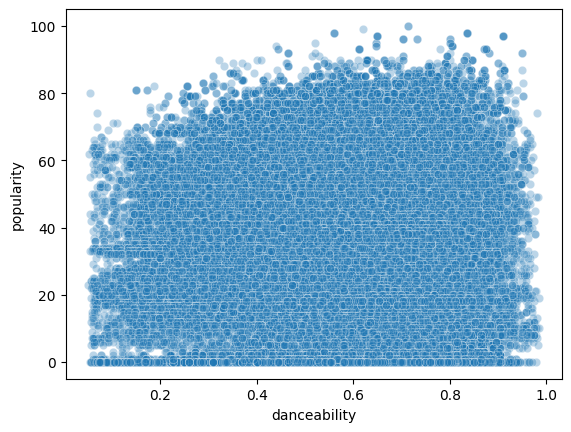

In [44]:
#danceability and popularity
sns.scatterplot(x='danceability',y='popularity',data=df,alpha=0.3)

<Axes: xlabel='loudness', ylabel='popularity'>

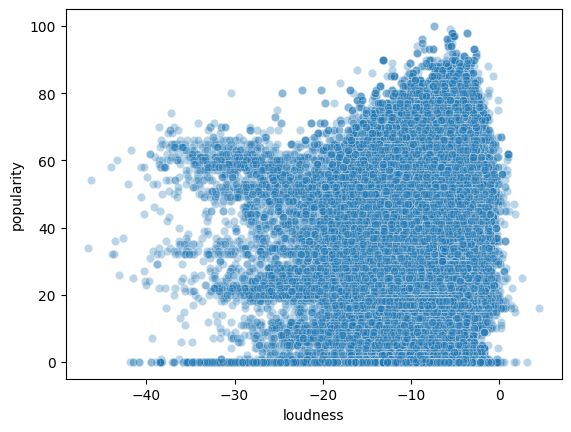

In [39]:
#loudness and popularity
sns.scatterplot(x='loudness',y='popularity',data=df,alpha=0.3)


<Axes: xlabel='acousticness', ylabel='popularity'>

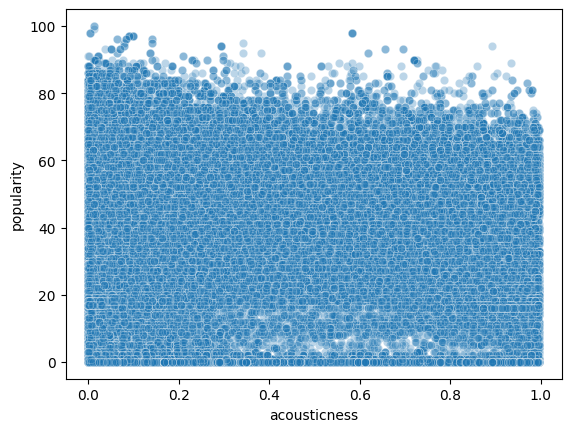

In [41]:
#acousticness and popularity
sns.scatterplot(x='acousticness',y='popularity',data=df,alpha=0.3)

<Axes: xlabel='tempo', ylabel='popularity'>

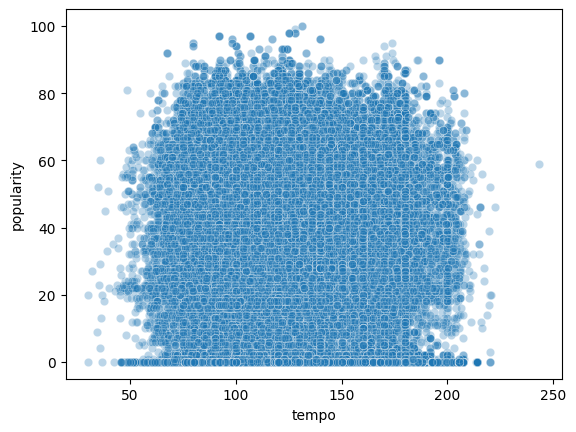

In [42]:
#tempo and popularity
sns.scatterplot(x='tempo',y='popularity',data=df,alpha=0.3)

**Artists**
Which artists appear most frequently?
Which artist has the highest average popularity?

In [ ]:
#frequently appearing
df['artists'].value_counts().head(10)

In [ ]:
#high avg popularity
fap=df.groupby('artists')
fap['popularity'].mean().sort_values(ascending=False).head(10)

**Explicit Songs**
Are explicit songs generally more popular?

In [ ]:
es=df.groupby('explicit')
print(es['popularity'].mean())
print(df['explicit'].value_counts())
sns.boxplot(x='explicit', y='popularity', data=df)
print(es['popularity'].median())

In [65]:
#High energy but low popularity:
df[(df['energy'] > 0.8) & (df['popularity'] < 20)][['track_name','artists','energy','popularity']].head(10)
#Very acoustic but still popular (the reverse case from your plan):
df[(df['acousticness'] > 0.8) & (df['popularity'] > 70)][['track_name','artists','acousticness','popularity']].head(10)
# High danceability but unpopular
df[(df['danceability'] > 0.8) & (df['popularity'] < 20)][['track_name','artists','danceability','popularity']].head(10)

# Very loud but unpopular
df[(df['loudness'] > -3) & (df['popularity'] < 20)][['track_name','artists','loudness','popularity']].head(10)

# High valence (happy-sounding) but very unpopular
df[(df['valence'] > 0.8) & (df['popularity'] < 10)][['track_name','artists','valence','popularity']].head(10)

,track_name,artists,valence,popularity
98,Hold On,KT Tunstall,0.805,0
197,Stumble,Freddie King,0.857,0
198,Paradise,Taj Mahal,0.862,0
1088,Nontsokolo,Hugh Masekela,0.942,0
1089,Soul Makossa,Manu Dibango,0.921,0
1092,District Six - Live,Hugh Masekela,0.858,0
1094,Women Of The Sun,Hugh Masekela,0.959,0
1098,District Six - Live,Hugh Masekela,0.858,0
1137,District Six - Live,Hugh Masekela,0.858,0
1146,District Six - Live,Hugh Masekela,0.858,0
